# Pasar las muestras por el modelo general

Toma todas las fotos de `data/samples/` y dibuja lo que detecta el modelo: **`product`** y **`gap`**.

## 1. Rutas

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

ROOT = Path.cwd().parent

SAMPLES_DIR = ROOT / "data/samples/bebidas"
MODEL_PATH = ROOT / "models/shelf-generic-yolo26m/best.pt"
PLANOGRAM_PATH = ROOT / "data/planograms/gondola_gaseosas.json"

## 2. Cargar el modelo

In [2]:
from ultralytics import YOLO

model = YOLO(MODEL_PATH)

## 3. Detectar y numerar

Cada detección lleva un número: de izquierda a derecha, empezando por el estante de abajo.

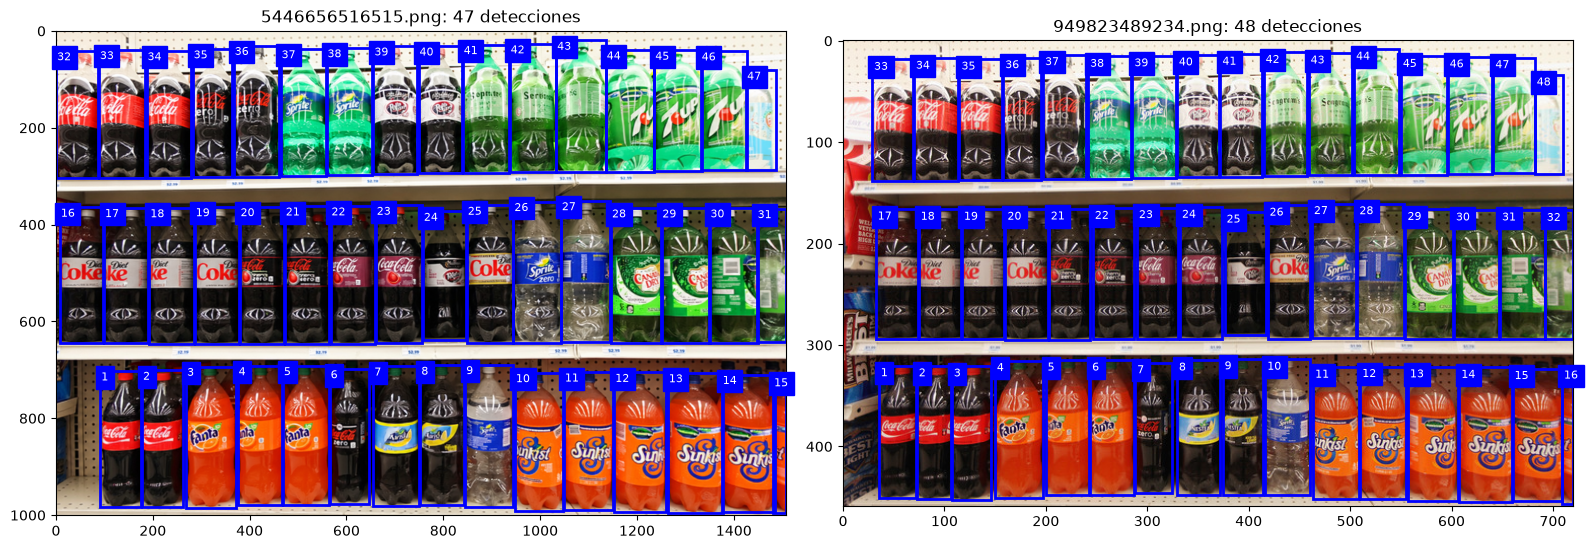

In [3]:
import math

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

from planogram import detect, group_rows

COLORS = {"product": "blue", "gap": "red"}
images = sorted(p for p in SAMPLES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"})

cols = min(3, len(images))
fig, axes = plt.subplots(math.ceil(len(images) / cols), cols, figsize=(8 * cols, 6 * math.ceil(len(images) / cols)), squeeze=False)

for ax, path in zip(axes.flat, images):
    image = Image.open(path).convert("RGB")
    rows = group_rows(detect(model, image, conf=0.25))[::-1]  # estantes de abajo hacia arriba
    detections = [d for row in rows for d in row]

    ax.imshow(image)
    for n, d in enumerate(detections, start=1):
        x1, y1, x2, y2 = d.box
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, color=COLORS[d.sku], lw=2))
        ax.text(x1 + 2, y1 + 2, str(n), color="white", fontsize=8, va="top", backgroundcolor=COLORS[d.sku])
    ax.set_title(f"{path.name}: {len(detections)} detecciones")

for ax in axes.flat[len(images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Cruce con el planograma: quiebres de stock

El planograma dice qué grupos de productos van en cada estante y cuántos frentes tiene cada uno, de izquierda a derecha.
Cada producto detectado se empareja con el frente esperado más cercano; **los frentes que quedan vacíos son quiebres**.

En la foto: verde = frente con producto, rojo = falta (con el SKU que debería estar).

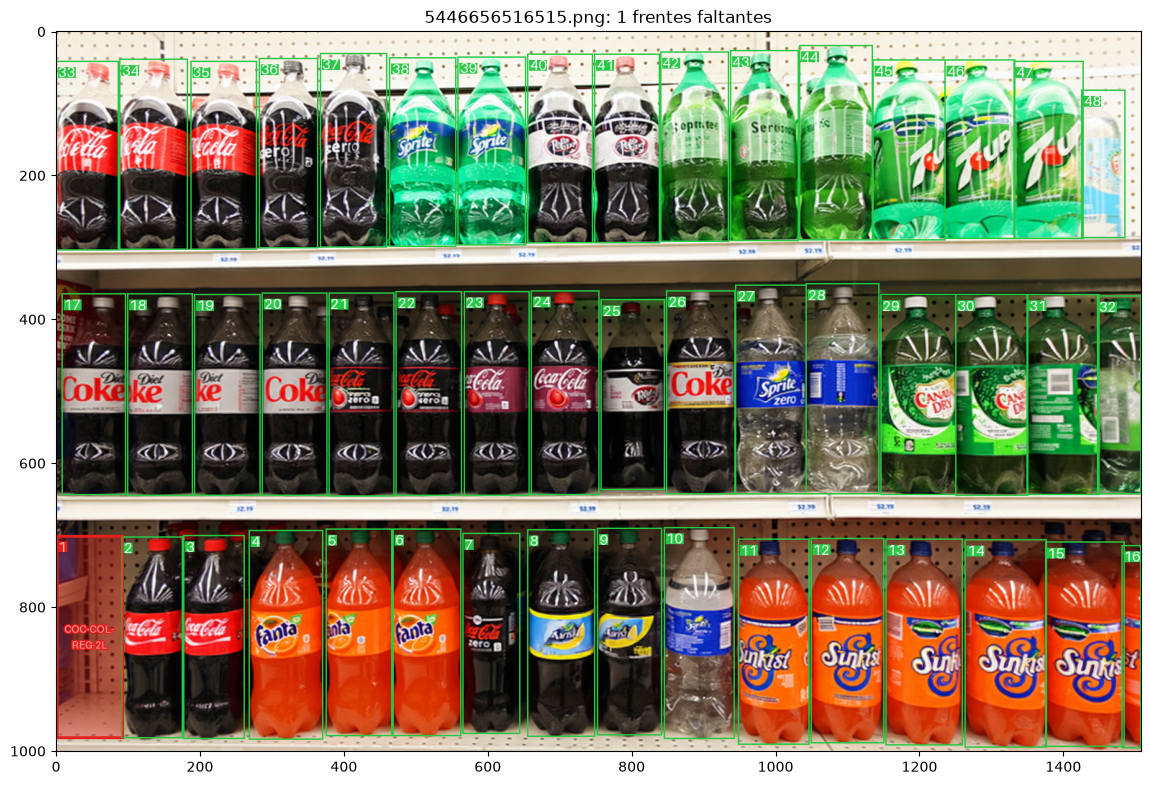

,nivel,sku,esperados,detectados,faltan,estado
0,1,COC-COL-REG-2L,3,2,1,quiebre parcial


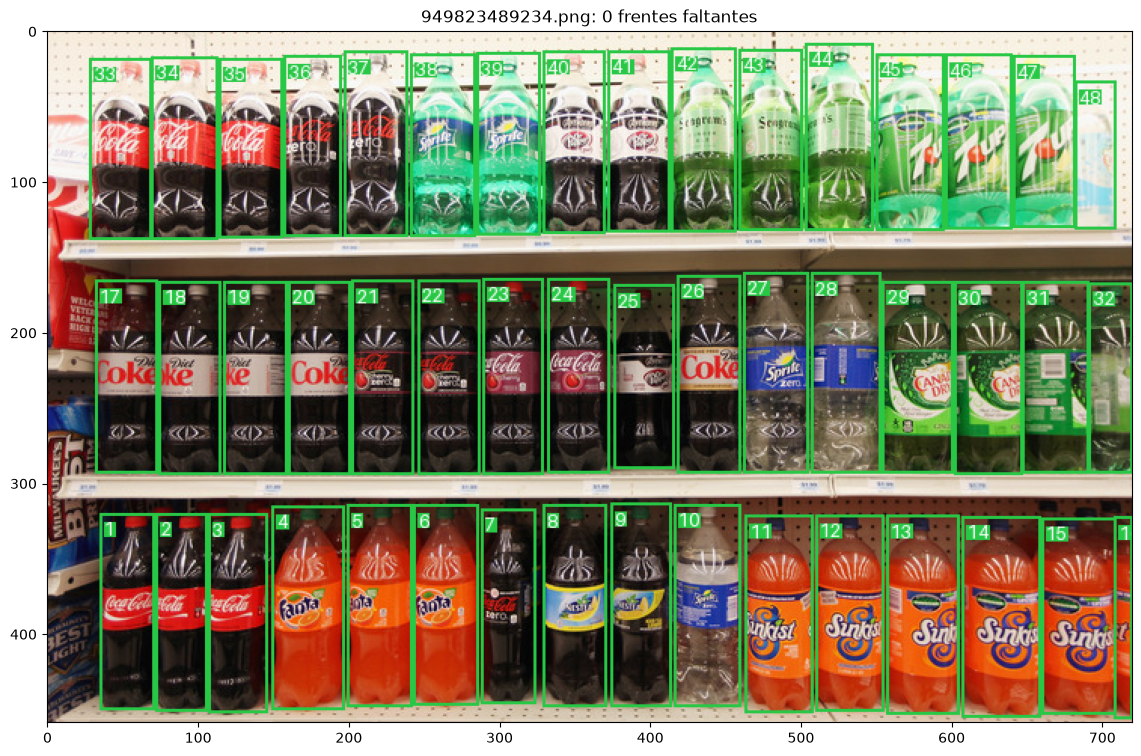

,nivel,sku,esperados,detectados,faltan,estado


In [4]:
import json

from planogram.stockout import find_stockouts, stockout_table
from planogram.visualization import draw_stockouts

planogram = json.loads(PLANOGRAM_PATH.read_text())

for path in images:
    image = Image.open(path).convert("RGB")
    products = [d for d in detect(model, image, conf=0.25) if d.sku == "product"]
    facings = find_stockouts(planogram, group_rows(products)[::-1])
    table = stockout_table(facings)

    plt.figure(figsize=(14, 10))
    plt.imshow(draw_stockouts(image, facings))
    plt.title(f"{path.name}: {table.faltan.sum()} frentes faltantes")
    plt.axis("on")
    plt.show()
    display(table[table.estado != "ok"])

## 5. Reporte en PDF

Un solo reporte para todas las fotos, con estilo de paper LaTeX: resumen, metodología, resultados por foto
(figura + tabla de quiebres), recomendaciones de reposición y conclusión. Pensado para el área comercial.
Se compila con `pdflatex` y queda en `outputs/reportes/` junto con el `.tex` (se puede abrir en Overleaf).

In [5]:
from datetime import datetime

from planogram.report import Shot, stockout_report

# configuración del reporte
AUTOR = "511521822"
FECHA = datetime.now().astimezone().date()  # fecha de la auditoría
META = 0.95  # disponibilidad objetivo (0 a 1)
CRITICO = 0.85  # por debajo de esto, la situación es crítica
METODOLOGIA = r"""Se tomaron <<n_fotos_texto>> de la góndola. Un modelo de visión computacional (YOLO) detecta cada
producto visible en la imagen y lo ubica en su estante. Luego se compara con el planograma: cada \emph{frente}
(espacio de un producto, de izquierda a derecha) se empareja con el producto detectado más cercano, y los frentes que
quedan sin producto se cuentan como \emph{quiebres}."""  # texto LaTeX; <<n_fotos_texto>> se reemplaza por "N fotos"
REPORT_PATH = ROOT / "outputs/reportes" / f"reporte_{planogram['gondola_id']}.pdf"

shots = []
for path in images:
    image = Image.open(path).convert("RGB")
    products = [d for d in detect(model, image, conf=0.25) if d.sku == "product"]
    shots.append(Shot(path.name, image, find_stockouts(planogram, group_rows(products)[::-1])))

pdf = stockout_report(
    shots, planogram, REPORT_PATH,
    autor=AUTOR, fecha=FECHA, meta=META, critico=CRITICO, metodologia=METODOLOGIA,
)
print("PDF:", pdf)

PDF: /home/luis/Desktop/ai/computer-vision/outputs/reportes/reporte_gondola_gaseosas.pdf
